<a href="https://colab.research.google.com/github/Jothini-Venkidusamy/Jothini-Codebooster-2026/blob/main/Day3/MiniProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
API_KEY = '9b5026518f01053bd2b3128aeb47214c'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']

print(f'API Configured for{len(CITIES)} CITIES')
print(f'Cities: {CITIES}')


API Configured for8 CITIES
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [ ]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,            # City name query parameter
      'appid': api_key,     # Authentication key
      'units': 'metric'     # Returns temperature in Celcius
  }
  # params in a dictionary - requests will encode it into the URL: ?q=Mumbai&appid=KEY&units=metric

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)
    #requests.get() sends an HTTP GET request to BASE URL
    #timeout=10 waits max for 10 seconds; raise error if no response

    if response.status_code==200:
      #status_code 200 = HTTP OK = request was successful
      data = response.json()
      # .json parses the JSON text body into a Python dictionary

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0) #.get('visibility', 0) is safe access: return 0 if key is missing,
          #1000 - convert meters to kilimeters (integer division)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record['temperature']}°C', {record['condition']})
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...
 Fetching: Mumbai...34.0°C {'Haze'}
{'city': 'Mumbai', 'temperature': 34.0, 'feels_like': 41.0, 'humidity': 59, 'pressure': 1009, 'wind_speed': 6.17, 'condition': 'Haze', 'visibility': 7000}
 Fetching: Delhi...44.0°C {'Clear Sky'}
{'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7000}
 Fetching: Bangalore...29.8°C {'Scattered Clouds'}
{'city': 'Bangalore', 'temperature': 29.8, 'feels_like': 31.5, 'humidity': 55, 'pressure': 1009, 'wind_speed': 4.63, 'condition': 'Scattered Clouds', 'visibility': 8000}
 Fetching: Chennai...36.0°C {'Few Clouds'}
{'city': 'Chennai', 'temperature': 36.0, 'feels_like': 43.0, 'humidity': 54, 'pressure': 1005, 'wind_speed': 5.14, 'condition': 'Few Clouds', 'visibility': 6000}
 Fetching: Hyderabad...31.2°C {'Broken Clouds'}
{'city': 'Hyderabad', 'temperature': 31.2, 'feels_like': 33.2, 'humidity': 51, 'pressure': 1008, 'wind_speed': 8.75

In [6]:
import pandas as pd
weather_df = pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index= False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing Values: {weather_df.isnull().sum().sum()}')
print(f'\nDataTypes: ')
print(weather_df.dtypes)

Weather DataFrame created:
     city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
   Mumbai         34.0        41.0        59      1009        6.17             Haze        7000
    Delhi         44.0        41.1        10       999        5.14        Clear Sky        7000
Bangalore         29.8        31.5        55      1009        4.63 Scattered Clouds        8000
  Chennai         36.0        43.0        54      1005        5.14       Few Clouds        6000
Hyderabad         31.2        33.2        51      1008        8.75    Broken Clouds        6000
  Kolkata         32.0        37.6        62      1001        4.12             Haze        5000
     Pune         36.9        36.8        27      1008        3.76  Overcast Clouds       10000
   Jaipur         42.6        41.3        15      1001        5.14             Haze        5000

Shape: (8, 8)
Missing Values: 0

DataTypes: 
city            object
temperature    float64
feels_like     fl

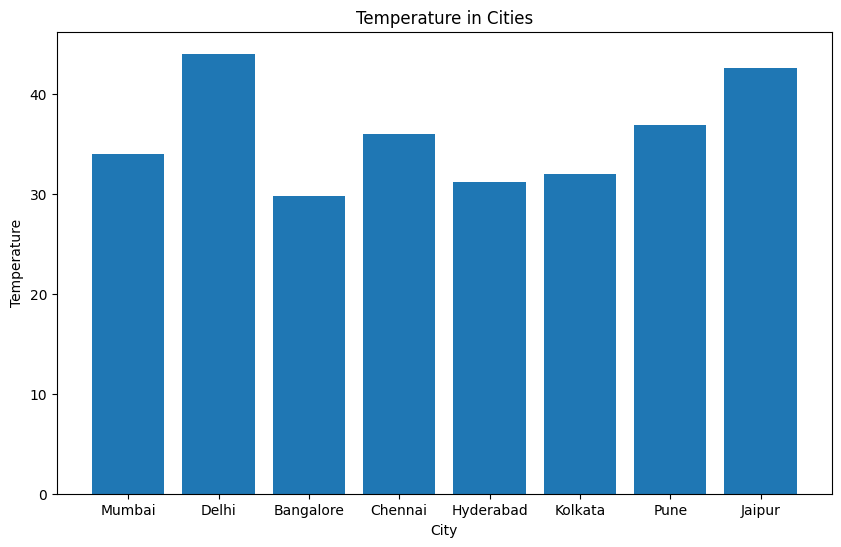

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

plt.figure(figsize=(10,6))
plt.bar(weather_df['city'],weather_df['temperature'])
plt.title('Temperature in Cities')
plt.xlabel('City')
plt.ylabel('Temperature')
plt.show()
